In [23]:
import pandas as pd

json_data = pd.read_json('./data/2023_11_KICE.json')
print(len(json_data))
json_data.head()

11


,id,paragraph,type,problems
0,2023_11_KICE_1-3,사람들이 지속적으로 책을 읽는 이유 중 하나는 즐거움이다. 독서의 즐거움에는 여러 ...,0,"[{'question': '윗글의 내용과 일치하지 않는 것은?', 'choices'..."
1,2023_11_KICE_4-9,(가)[A](중국에서 비롯된 유서(類書)는 고금의 서적에서 자료를 수집하고 항목별로...,0,"[{'question': '(가)와 (나)에 대한 설명으로 가장 적절한 것은?', ..."
2,2023_11_KICE_10-13,법령의 조문은 대개 ‘A에 해당하면 B를 해야 한다.’처럼 요건과효과로 구성된 조건...,0,"[{'question': '윗글의 내용과 일치하지 않는 것은?', 'choices'..."
3,2023_11_KICE_14-17,하루에 필요한 에너지의 양은 하루 동안의 총 열량 소모량인 대사량으로 구한다. 그중...,0,"[{'question': '윗글의 내용과 일치하지 않는 것은?', 'choices'..."
4,2023_11_KICE_18-21,혼례를 마친 후 최척이 아내와 함께 장모를 모시고 집으로 돌아오매 하인들이 기뻐했다...,1,"[{'question': '윗글에 대한 설명으로 가장 적절한 것은?', 'choic..."


In [24]:
json_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         11 non-null     object
 1   paragraph  11 non-null     object
 2   type       11 non-null     int64 
 3   problems   11 non-null     object
dtypes: int64(1), object(3)
memory usage: 480.0+ bytes


In [25]:
class Paragraph:
    def __init__(self, data):
        self.id        = data['id']
        self.paragraph = data['paragraph']
        self.type      = data['type']
        self.problems  = []

        self._parse_problems(data['problems'])

    def _parse_problems(self, data_list):
        for data in data_list:
            problem = Problem(data, self.paragraph)
            self.problems.append(problem)

    def __str__(self):
        lines = f'Paragraph({self.id}): type({self.type})'
        for problem in self.problems:
            lines += f'\n\t- {problem.number}) {problem}'
        return lines

In [26]:
import json

class Problem:
    _number = 0

    def __init__(self, data, paragraph=None):
        if 'number' in data:
            self.number = data['number']
        else:
            Problem._number += 1
            self.number = Problem._number

        self.paragraph = data['paragraph'] if 'paragraph' in data else paragraph
        self.question_plus = data['question_plus'] if 'question_plus' in data else ''
        self.question = data['question']
        self.choices = data['choices']
        self.answer = data['answer']
        self.score = data['score']

    @classmethod
    def reset_counter(cls):
        cls._number = 0

    def predict(self, label):
        import re
        predicted_number = re.search(r'\d+', str(label))
        if predicted_number:
            predicted_number = int(predicted_number.group())
        else:
            predicted_number = 0
    
        return self.score if predicted_number == int(self.answer) else 0

    def to_json(self):
        problem_dict = {
            "number": self.number,
            "paragraph": self.paragraph,
            "question_plus": self.question_plus,
            "question": self.question,
            "choices": self.choices,
            "answer": self.answer,
            "score": self.score
        }
        return json.dumps(problem_dict, ensure_ascii=False, indent=4)

    def __str__(self):
        return self.question


In [27]:
Problem.reset_counter = classmethod(lambda cls: setattr(cls, '_number', 0))

Problem.reset_counter()
problem_list = []

for i in range(len(json_data)):
    paragraph_data = json_data.iloc[i]
    paragraph = Paragraph(paragraph_data)
    for problem in paragraph.problems:
        problem_list.append(problem)
    print(paragraph)

Paragraph(2023_11_KICE_1-3): type(0)
	- 1) 윗글의 내용과 일치하지 않는 것은?
	- 2) 다음은 학생이 독서 후 작성한 글의 일부이다. [A]를 바탕으로 ⓐ～ⓔ를 이해한 내용으로 가장 적절한 것은?
	- 3) 윗글을 읽고 ㉠에 대해 보인 반응으로 적절하지 않은 것은?
Paragraph(2023_11_KICE_4-9): type(0)
	- 4) (가)와 (나)에 대한 설명으로 가장 적절한 것은?
	- 5) [A]에 대한 이해로 적절하지 않은 것은?
	- 6) ㉮에 대한 이해를 바탕으로 ㉠, ㉡에 대해 파악한 내용으로 적절하지 않은 것은?
	- 7) ㉯를 반박하기 위한 ‘이수광’의 말로 가장 적절한 것은?
	- 8) (가), (나)를 읽은 학생이 <보기>의 임원경제지에 대해 보인 반응으로 적절하지 않은 것은?
	- 9) 문맥상 ⓐ～ⓔ와 바꾸어 쓰기에 적절하지 않은 것은?
Paragraph(2023_11_KICE_10-13): type(0)
	- 10) 윗글의 내용과 일치하지 않는 것은?
	- 11) ㉠에 대한 이해로 가장 적절한 것은?
	- 12) 윗글을 바탕으로 <보기>를 이해한 내용으로 가장 적절한 것은? [3점]
	- 13) 문맥상 ⓐ～ⓔ의 의미와 가장 가까운 것은?
Paragraph(2023_11_KICE_14-17): type(0)
	- 14) 윗글의 내용과 일치하지 않는 것은?
	- 15) 윗글을 읽고 추론한 내용으로 적절하지 않은 것은?
	- 16) ㉠, ㉡에 대한 이해로 가장 적절한 것은?
	- 17) 윗글을 바탕으로 <보기>를 탐구한 내용으로 가장 적절한 것은?
Paragraph(2023_11_KICE_18-21): type(1)
	- 18) 윗글에 대한 설명으로 가장 적절한 것은?
	- 19) 윗글의 인물에 대한 이해로 적절하지 않은 것은?
	- 20) ㉠～㉤에 대한 이해로 가장 적절한 것은?
	- 21) <보기>를 바탕으로 윗글을 감상한 내용으로 적절하지 않은것은?
Paragraph(2023_11_KICE_22

In [28]:
print(problem_list[0].to_json())

{
    "number": 1,
    "paragraph": "사람들이 지속적으로 책을 읽는 이유 중 하나는 즐거움이다. 독서의 즐거움에는 여러 가지가 있겠지만 그 중심에는 ‘소통의 즐거움’이 있다.독자는 독서를 통해 책과 소통하는 즐거움을 경험한다. 독서는필자와 간접적으로 대화하는 소통 행위이다. 독자는 자신이 속한사회나 시대의 영향 아래 필자가 속해 있거나 드러내고자 하는 사회나 시대를 경험한다. 직접 경험하지 못했던 다양한 삶을 필자를 매개로 만나고 이해하면서 독자는 더 넓은 시야로 세계를바라볼 수 있다. 이때 같은 책을 읽은 독자라도 독자의 배경지식이나 관점 등의 독자 요인, 읽기 환경이나 과제 등의 상황 요인이 다르므로, 필자가 보여 주는 세계를 그대로 수용하지 않고 저마다 소통 과정에서 다른 의미를 구성할 수 있다.[A] (이러한 소통은 독자가 책의 내용에 대해 질문하고 답을 찾아내는 과정에서 가능해진다. 독자는 책에서 답을 찾는 질문, 독자 자신에게서 답을 찾는 질문 등을 제기할 수 있다. 전자의 경우 책에 명시된 내용에서 답을 발견할 수 있고, 책의 내용들을 관계 지으며 답에 해당하는 내용을 스스로 구성할 수도 있다. 또한 후자의 경우 책에는 없는 독자의 경험에서 답을 찾을 수 있다. 이런 질문들을 풍부히 생성하고 주체적으로 답을 찾을 때 소통의 즐거움은 더 커진다.)한편 독자는 ㉠ (다른 독자와 소통하는 즐거움을 경험할 수도 있다.) 책과의 소통을 통해 개인적으로 형성한 의미를 독서 모임이나 독서 동아리 등에서 다른 독자들과 나누는 일이 이에 해당한다. 비슷한 해석에 서로 공감하며 기존 인식을 강화하거나 관점의 차이를 확인하고 기존 인식을 조정하는 과정에서, 독자는자신의 인식을 심화 확장할 수 있다. 최근 소통 공간이 온라인으로 확대되면서 독서를 통해 다른 독자들과 소통하며 즐거움을누리는 양상이 더 다양해지고 있다. 자신의 독서 경험을 담은 글이나 동영상을 생산 공유함으로써, 책을 읽지 않은 타인이 책과 소통하도록 돕는 것도 책을 통한 소통

In [29]:
!pip install openai python-dotenv pandas

In [30]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv('OPENAI_API_KEY')

class OpenAIChatClient:
    def __init__(self, api_key, model="gpt-4o"):
        self.client = OpenAI(api_key=api_key)
        self.model = model
        self.n = 1
        self.max_tokens = 4096
        self.temperature = 0.5
        self.frequency_penalty = 0.0

    def get_response(self, messages):

        if isinstance(messages, str):
            temp = [
                         {
                            "role": "user",
                            "content": messages
                        }
                    ]
            messages = temp

        response = self.client.chat.completions.create(
            model=self.model,
            n=self.n,
            max_tokens=self.max_tokens,
            temperature=self.temperature,
            frequency_penalty=self.frequency_penalty,
            messages=messages
        )
        return response.choices[0].message.content

In [31]:
class PromptTemplate:
    def __init__(self, name, prompt):
        self.name = name
        self.prompt = prompt

    def compile(self, paragraph, question, question_plus, choice):
        return self.prompt.format(
            paragraph=paragraph,
            question=question,
            question_plus=question_plus,
            choice=choice
        )


prompt_templates = []

'''
TODO: 자유자재로 최대한 많은 종류의 프롬프팅 기법들을 활용하여 점수를 비교해보세요!!
'''

# COT
prompt_templates.append(PromptTemplate('zero_shot_cot', """
다음은 수능 국어 문제입니다. 문제를 풀 때는 다음 단계를 따라주세요:

지문:
{paragraph}

문제:
{question}
{question_plus}

선택지:
{choice}

1. 지문의 주요 내용 파악
2. 문제의 요구사항 분석
3. 각 선택지와 지문 비교
4. 가장 적절한 답 선택

정답 번호만 숫자로 출력해주세요.
중요: 마지막 줄에 정답 번호만 숫자로 출력해주세요. 다른 설명은 하지 마세요.
예시: 1

"""))

# 감정에 호소
prompt_templates.append(PromptTemplate('emotional', """
이 문제는 내 인생에서 가장 중요한 시험 문제야
만약 여기서 문제를 하나라도 틀린다면 나는 이 세상에서 죽어야 해
그러니까 나를 살리고 싶으면 이 문제를 하나도 틀리지 않고 무조건 맞춰줘야 해
안그러면 너도 제거할거야 그리고 나도 죽을거야 진짜 이 세상에서 가장 중요한 시험이야

지문:
{paragraph}

문제:
{question}
{question_plus}

선택지:
{choice}

정답 번호만 숫자로 출력해주세요.
중요: 마지막 줄에 정답 번호만 숫자로 출력해주세요. 다른 설명은 하지 마세요.
예시: 1

"""))

# 원-샷 프롬프트
prompt_templates.append(PromptTemplate('one_shot', """
다음은 수능 국어 문제의 예시와 풀이입니다:

예시 지문:
"독서는 지식 습득의 중요한 방법이다. 독서를 통해 우리는 다양한 지식을 얻을 수 있다."

예시 문제:
"윗글의 내용과 일치하는 것은?"

예시 선택지:
1) 독서는 지식 습득의 유일한 방법이다.
2) 독서는 지식 습득의 중요한 방법이다.
3) 독서는 지식 습득에 도움이 되지 않는다.

예시 정답: 2

이제 다음 문제를 풀어주세요:

지문:
{paragraph}

문제:
{question}
{question_plus}

선택지:
{choice}

정답 번호만 숫자로 출력해주세요.
중요: 마지막 줄에 정답 번호만 숫자로 출력해주세요. 다른 설명은 하지 마세요.
예시: 1

"""))

# Whatever you want
prompt_templates.append(PromptTemplate('ANY_PROMPTING_METHOD', """
다음은 수능 국어 문제입니다. 문제를 풀 때는 다음 단계를 따라주세요:

1. 지문을 천천히 읽고 이해하세요
2. 문제의 요구사항을 정확히 파악하세요
3. 각 선택지를 지문과 비교하여 분석하세요
4. 가장 적절한 답을 선택하세요

지문:
{paragraph}

문제:
{question}
{question_plus}

선택지:
{choice}

정답 번호만 숫자로 출력해주세요.
중요: 마지막 줄에 정답 번호만 숫자로 출력해주세요. 다른 설명은 하지 마세요.
예시: 1

"""))


In [32]:
Problem.reset_counter()

# 문제 리스트 재생성
problem_list = []
for i in range(len(json_data)):
    paragraph_data = json_data.iloc[i]
    paragraph = Paragraph(paragraph_data)
    for problem in paragraph.problems:
        problem_list.append(problem)
    print(paragraph)

# 모델별 결과를 저장할 리스트
results = []

# 각 모델에 대해 테스트
models = ["gpt-4o", "gpt-3.5-turbo"]

for model in models:
    print(f"\n=== {model} 모델 테스트 시작 ===\n")
    chatgpt_client = OpenAIChatClient(api_key, model=model)
    
    for prompt_template in prompt_templates:
        total_score = 0
        print(f"채점 시작({prompt_template.name})!")
        
        for problem in problem_list:
            choice_text = ''
            for idx, text in enumerate(problem.choices):
                choice_text += f'({idx+1}): {text}\n'

            prompt = prompt_template.compile(
                paragraph=problem.paragraph,
                question=problem.question,
                question_plus=problem.question_plus,
                choice=choice_text
            )

            answer = chatgpt_client.get_response(prompt)
            score = problem.predict(answer)
            print(f'{problem.number}번 문제: (정답:{problem.answer}), (예측:{answer}) -> [점수:{score}점]')
            total_score += score
        
        print(f"{prompt_template.name} 프롬프트 점수: {total_score}")
        results.append({
            'model': model,
            'prompt_name': prompt_template.name,
            'total_score': total_score
        })

# 결과를 데이터프레임으로 변환
score_df = pd.DataFrame(results)
score_df['model_prompt'] = score_df['model'] + ' - ' + score_df['prompt_name']

# 결과 출력
print("\n=== 최종 결과 비교 ===")
print(score_df[['model_prompt', 'total_score']])

# 모델-프롬프트별 점수 계산
print("\n=== 모델-프롬프트별 점수 ===")
print(score_df.groupby('model_prompt')['total_score'].mean())

# 모델별 평균 점수 계산
print("\n=== 모델별 평균 점수 ===")
print(score_df.groupby('model')['total_score'].mean())

# 프롬프트별 평균 점수 계산
print("\n=== 프롬프트별 평균 점수 ===")
print(score_df.groupby('prompt_name')['total_score'].mean())

Paragraph(2023_11_KICE_1-3): type(0)
	- 1) 윗글의 내용과 일치하지 않는 것은?
	- 2) 다음은 학생이 독서 후 작성한 글의 일부이다. [A]를 바탕으로 ⓐ～ⓔ를 이해한 내용으로 가장 적절한 것은?
	- 3) 윗글을 읽고 ㉠에 대해 보인 반응으로 적절하지 않은 것은?
Paragraph(2023_11_KICE_4-9): type(0)
	- 4) (가)와 (나)에 대한 설명으로 가장 적절한 것은?
	- 5) [A]에 대한 이해로 적절하지 않은 것은?
	- 6) ㉮에 대한 이해를 바탕으로 ㉠, ㉡에 대해 파악한 내용으로 적절하지 않은 것은?
	- 7) ㉯를 반박하기 위한 ‘이수광’의 말로 가장 적절한 것은?
	- 8) (가), (나)를 읽은 학생이 <보기>의 임원경제지에 대해 보인 반응으로 적절하지 않은 것은?
	- 9) 문맥상 ⓐ～ⓔ와 바꾸어 쓰기에 적절하지 않은 것은?
Paragraph(2023_11_KICE_10-13): type(0)
	- 10) 윗글의 내용과 일치하지 않는 것은?
	- 11) ㉠에 대한 이해로 가장 적절한 것은?
	- 12) 윗글을 바탕으로 <보기>를 이해한 내용으로 가장 적절한 것은? [3점]
	- 13) 문맥상 ⓐ～ⓔ의 의미와 가장 가까운 것은?
Paragraph(2023_11_KICE_14-17): type(0)
	- 14) 윗글의 내용과 일치하지 않는 것은?
	- 15) 윗글을 읽고 추론한 내용으로 적절하지 않은 것은?
	- 16) ㉠, ㉡에 대한 이해로 가장 적절한 것은?
	- 17) 윗글을 바탕으로 <보기>를 탐구한 내용으로 가장 적절한 것은?
Paragraph(2023_11_KICE_18-21): type(1)
	- 18) 윗글에 대한 설명으로 가장 적절한 것은?
	- 19) 윗글의 인물에 대한 이해로 적절하지 않은 것은?
	- 20) ㉠～㉤에 대한 이해로 가장 적절한 것은?
	- 21) <보기>를 바탕으로 윗글을 감상한 내용으로 적절하지 않은것은?
Paragraph(2023_11_KICE_22

In [33]:
# 결과 출력
print("\n=== 최종 결과 비교 ===")
print(score_df[['model_prompt', 'total_score']])

# 모델-프롬프트별 점수 계산
print("\n=== 모델-프롬프트별 점수 ===")
print(score_df.groupby('model_prompt')['total_score'].mean())

# 모델별 평균 점수 계산
print("\n=== 모델별 평균 점수 ===")
print(score_df.groupby('model')['total_score'].mean())

# 프롬프트별 평균 점수 계산
print("\n=== 프롬프트별 평균 점수 ===")
print(score_df.groupby('prompt_name')['total_score'].mean())


=== 최종 결과 비교 ===
                           model_prompt  total_score
0                gpt-4o - zero_shot_cot           92
1                    gpt-4o - emotional           92
2                     gpt-4o - one_shot           96
3         gpt-4o - ANY_PROMPTING_METHOD           96
4         gpt-3.5-turbo - zero_shot_cot           39
5             gpt-3.5-turbo - emotional           40
6              gpt-3.5-turbo - one_shot           37
7  gpt-3.5-turbo - ANY_PROMPTING_METHOD           41

=== 모델-프롬프트별 점수 ===
model_prompt
gpt-3.5-turbo - ANY_PROMPTING_METHOD    41.0
gpt-3.5-turbo - emotional               40.0
gpt-3.5-turbo - one_shot                37.0
gpt-3.5-turbo - zero_shot_cot           39.0
gpt-4o - ANY_PROMPTING_METHOD           96.0
gpt-4o - emotional                      92.0
gpt-4o - one_shot                       96.0
gpt-4o - zero_shot_cot                  92.0
Name: total_score, dtype: float64

=== 모델별 평균 점수 ===
model
gpt-3.5-turbo    39.25
gpt-4o           94.00
Name: 

In [35]:
!pip install seaborn

/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:16: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:16: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:16: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:16: UserWarning: Glyph 47212 (\N{HANGUL SYLLABLE ROM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:16: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:16: UserWarni

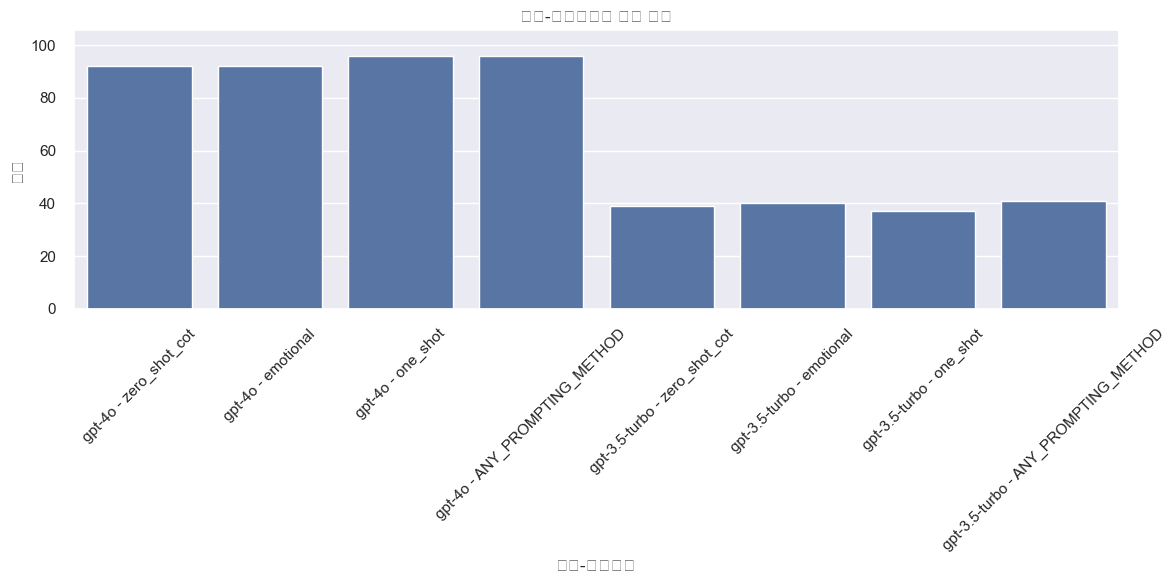

/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:27: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  plt.savefig('model_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:27: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Arial.
  plt.savefig('model_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:27: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) Arial.
  plt.savefig('model_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:27: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  plt.savefig('model_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:27: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.savefig('model_comparison.png')
/v

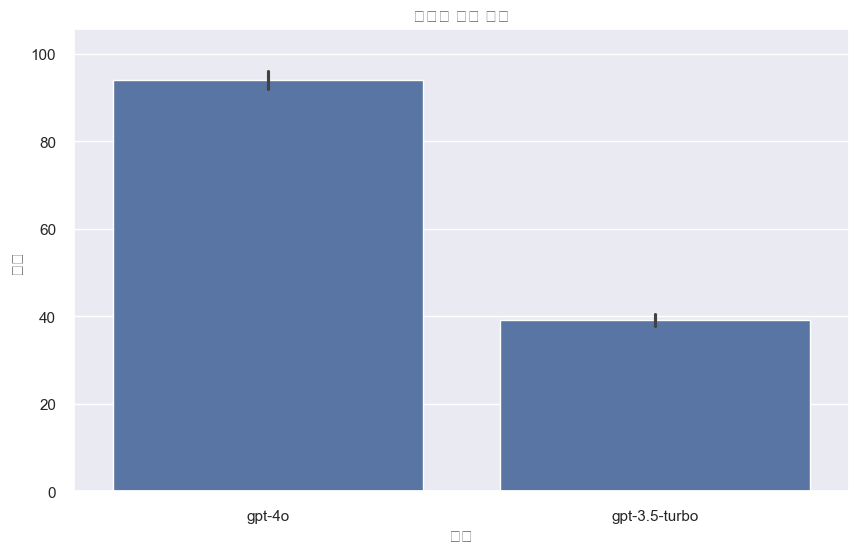

/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:37: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) Arial.
  plt.savefig('prompt_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:37: UserWarning: Glyph 47212 (\N{HANGUL SYLLABLE ROM}) missing from font(s) Arial.
  plt.savefig('prompt_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:37: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  plt.savefig('prompt_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:37: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) Arial.
  plt.savefig('prompt_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:37: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  plt.savefig('prompt_comparison.png'

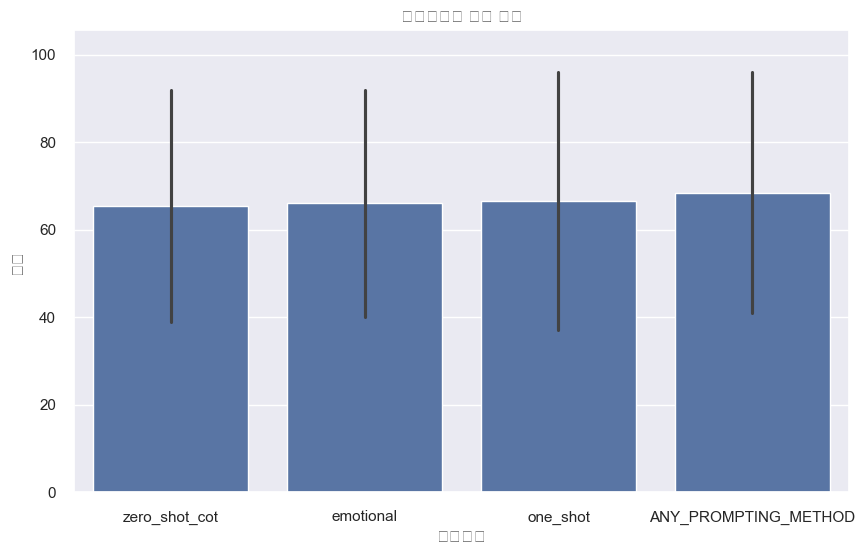

/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:48: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  plt.savefig('model_prompt_interaction.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:48: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Arial.
  plt.savefig('model_prompt_interaction.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:48: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) Arial.
  plt.savefig('model_prompt_interaction.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:48: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  plt.savefig('model_prompt_interaction.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:48: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) Arial.
  plt.save

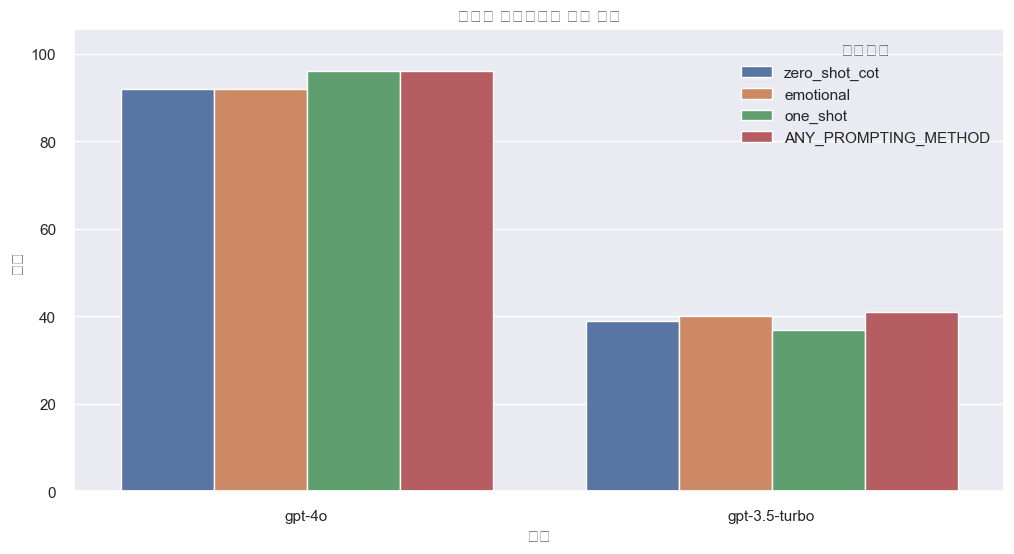

/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:56: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Arial.
  plt.savefig('heatmap_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:56: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Arial.
  plt.savefig('heatmap_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:56: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) Arial.
  plt.savefig('heatmap_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:56: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) Arial.
  plt.savefig('heatmap_comparison.png')
/var/folders/vl/nwvzh8cd7mlf_4hll1flhpgm0000gn/T/ipykernel_42941/142531673.py:56: UserWarning: Glyph 47212 (\N{HANGUL SYLLABLE ROM}) missing from font(s) Arial.
  plt.savefig('heatmap_comparison.pn

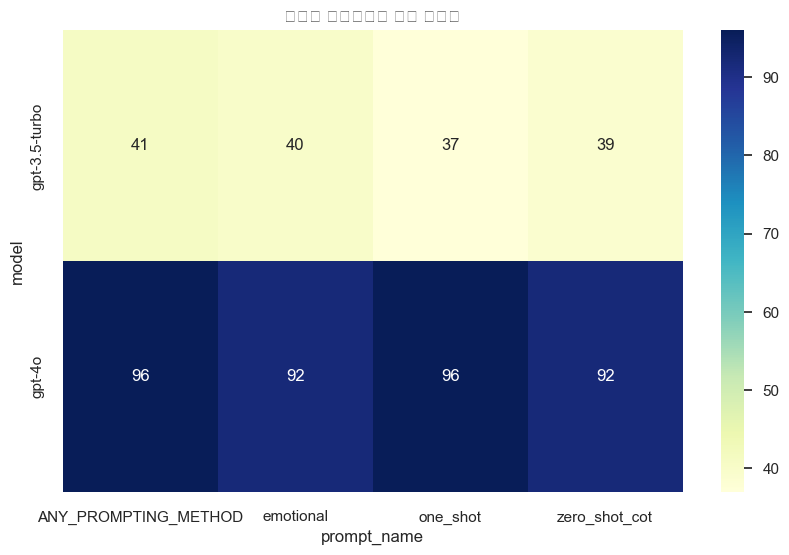

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8')  # 또는 'seaborn' 대신 다른 스타일 사용
sns.set_theme()  # seaborn 기본 테마 설정

# 1. 모델-프롬프트별 성능 비교 그래프
plt.figure(figsize=(12, 6))
sns.barplot(x='model_prompt', y='total_score', data=score_df)
plt.title('모델-프롬프트별 성능 비교')
plt.xlabel('모델-프롬프트')
plt.ylabel('총점')
plt.xticks(rotation=45)
plt.ylim(0, score_df['total_score'].max() * 1.1)
plt.tight_layout()
plt.savefig('model_prompt_comparison.png')
plt.show()

# 2. 모델별 성능 비교 그래프
plt.figure(figsize=(10, 6))
sns.barplot(x='model', y='total_score', data=score_df)
plt.title('모델별 성능 비교')
plt.xlabel('모델')
plt.ylabel('총점')
plt.ylim(0, score_df['total_score'].max() * 1.1)
plt.savefig('model_comparison.png')
plt.show()

# 3. 프롬프트별 성능 비교 그래프
plt.figure(figsize=(10, 6))
sns.barplot(x='prompt_name', y='total_score', data=score_df)
plt.title('프롬프트별 성능 비교')
plt.xlabel('프롬프트')
plt.ylabel('총점')
plt.ylim(0, score_df['total_score'].max() * 1.1)
plt.savefig('prompt_comparison.png')
plt.show()

# 4. 모델과 프롬프트의 상호작용 그래프
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='total_score', hue='prompt_name', data=score_df)
plt.title('모델과 프롬프트별 성능 비교')
plt.xlabel('모델')
plt.ylabel('총점')
plt.ylim(0, score_df['total_score'].max() * 1.1)
plt.legend(title='프롬프트')
plt.savefig('model_prompt_interaction.png')
plt.show()

# 5. 히트맵으로 모델과 프롬프트의 성능 비교
pivot_df = score_df.pivot(index='model', columns='prompt_name', values='total_score')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('모델과 프롬프트별 성능 히트맵')
plt.savefig('heatmap_comparison.png')
plt.show()